In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
# Load the dataset
data = pd.read_csv("../Data/net worth by quarter.csv", encoding='ISO-8859-1')
data.head(10)

,observation_date,WFRBL99T999219,WFRBLB50107,WFRBLN09053,WFRBLN40080,WFRBLT01026,WFRBLTP1246
0,1989-07-01,2904281,717835,7765825,7294817,4661504,1757223
1,1989-10-01,2967026,710392,7887797,7439699,4780063,1813037
2,1990-01-01,2951042,733432,7860072,7526506,4747930,1796888
3,1990-04-01,3004228,711986,7946939,7646319,4844782,1840554
4,1990-07-01,2945256,743216,7844610,7716421,4724032,1778776
5,1990-10-01,3031065,767806,7978021,7827271,4899279,1868214
6,1991-01-01,3128758,777265,8123464,7964094,5083956,1955198
7,1991-04-01,3139715,780547,8115367,8041456,5088234,1948519
8,1991-07-01,3189524,833714,8177014,8185345,5168192,1978668
9,1991-10-01,3310678,854249,8363831,8334017,5401450,2090772


In [12]:
# rename columns to more descriptive bracket names
data.rename(columns={'WFRBLB50107': '0% to 50%'}, inplace=True)
data.rename(columns={'WFRBLN40080': '50% to 90%'}, inplace=True)
data.rename(columns={'WFRBLN09053': '90% to 99%'}, inplace=True)
data.rename(columns={'WFRBL99T999219': '99% to 99.9%'}, inplace=True)
data.rename(columns={'WFRBLTP1246': '99.9% to 100%'}, inplace=True)
data.rename(columns={'WFRBLT01026': '99% to 100%'}, inplace=True)

# drop overlapping 99% to 100% column
data.drop(columns=['99% to 100%'], inplace=True)

In [13]:
data.head(10)

,observation_date,99% to 99.9%,0% to 50%,90% to 99%,50% to 90%,99.9% to 100%
0,1989-07-01,2904281,717835,7765825,7294817,1757223
1,1989-10-01,2967026,710392,7887797,7439699,1813037
2,1990-01-01,2951042,733432,7860072,7526506,1796888
3,1990-04-01,3004228,711986,7946939,7646319,1840554
4,1990-07-01,2945256,743216,7844610,7716421,1778776
5,1990-10-01,3031065,767806,7978021,7827271,1868214
6,1991-01-01,3128758,777265,8123464,7964094,1955198
7,1991-04-01,3139715,780547,8115367,8041456,1948519
8,1991-07-01,3189524,833714,8177014,8185345,1978668
9,1991-10-01,3310678,854249,8363831,8334017,2090772


In [14]:
# Convert the date column to datetime format and filter the data to include only observations from 2004 to 2024
data['observation_date'] = pd.to_datetime(data['observation_date'])
filtered_data = data[(data['observation_date'].dt.year >= 2004) & (data['observation_date'].dt.year <= 2024)]

In [15]:
filtered_data.head(10)

,observation_date,99% to 99.9%,0% to 50%,90% to 99%,50% to 90%,99.9% to 100%
58,2004-01-01,8459950,1271227,18457391,17366467,4998170
59,2004-04-01,8583383,1315495,18747058,17626289,5062727
60,2004-07-01,8829100,1301414,19173523,17927833,5235743
61,2004-10-01,9188232,1339662,20006859,18514915,5581091
62,2005-01-01,9289867,1362075,20368587,18794466,5657173
63,2005-04-01,9547731,1377077,20991452,19103764,5916680
64,2005-07-01,9806864,1449548,21608750,19504098,6148305
65,2005-10-01,10000832,1513490,22096523,19914546,6316668
66,2006-01-01,10440425,1484937,22877699,20074410,6777676
67,2006-04-01,10400340,1489049,23004166,20135739,6781652


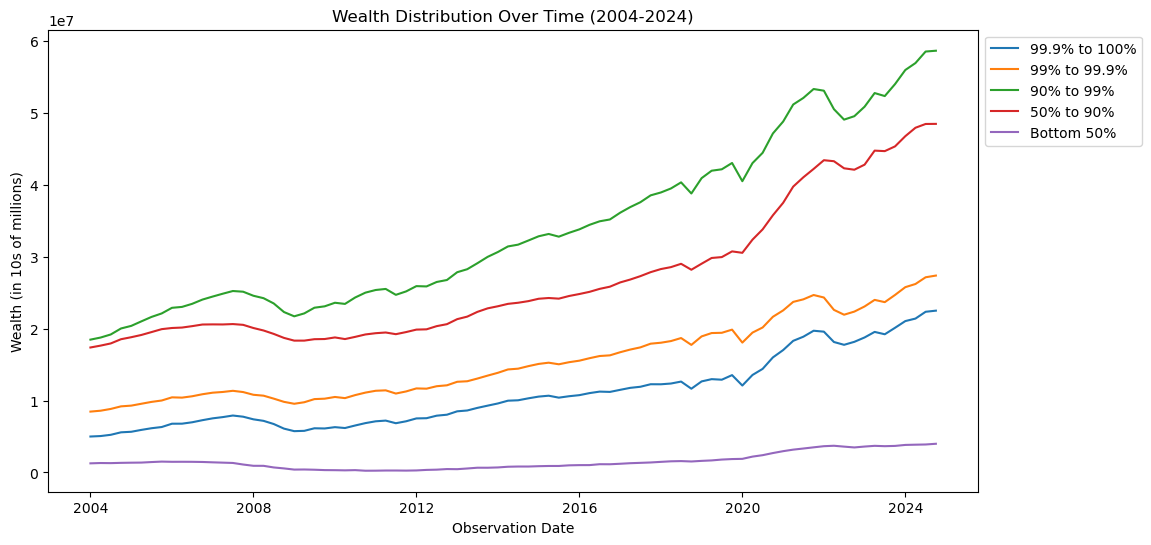

In [16]:
# Plotting the wealth distribution over time
plt.figure(figsize=(12, 6))
plt.plot(filtered_data['observation_date'], filtered_data['99.9% to 100%'], label='99.9% to 100%')
plt.plot(filtered_data['observation_date'], filtered_data['99% to 99.9%'], label='99% to 99.9%')
plt.plot(filtered_data['observation_date'], filtered_data['90% to 99%'], label='90% to 99%')
plt.plot(filtered_data['observation_date'], filtered_data['50% to 90%'], label='50% to 90%')
plt.plot(filtered_data['observation_date'], filtered_data['0% to 50%'], label='Bottom 50%')
plt.title('Wealth Distribution Over Time (2004-2024)')
plt.legend(loc = "upper left", bbox_to_anchor = (1.0, 1.0))
plt.xlabel('Observation Date')
plt.ylabel('Wealth (in 10s of millions)')
plt.show()